In [ ]:
#following tutorial: https://www.youtube.com/watch?v=7HPwo4wnJeA

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#import data and split into training and testing groups
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
#reshape training and testing output to 1d array
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [ ]:
#associate labels' name to label value in array
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [ ]:
#function for printing the image and label text of a value in training data at specified index
def plot_sample(X, y, index):
  plt.figure(figsize = (15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

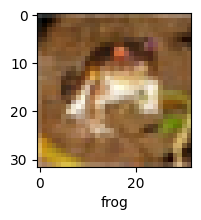

In [ ]:
plot_sample(X_train, y_train, 0)

In [ ]:
#normalize training and testing data to 0 <= value <= 1
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
#here's where we actually create a model
#this is just a normal NN, not a CNN
  #input layer
  #two hidden layers
  #output layer
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

#define:
  #optimizer: how to update weights
  #loss function to minimize
  #metrics to report during training and evaluation
ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])#, 'recall'])

#train the model on training data, run five training sessions
ann.fit(X_train, y_train, epochs=5)

#loss:
  #use categorical crossentropy for one hot encoded output
  #use the sparse version for just a value output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2981 - loss: 1.9383
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4180 - loss: 1.6441
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4517 - loss: 1.5547
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4786 - loss: 1.4833
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4913 - loss: 1.4413


In [ ]:
#test on data never seen before
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4892 - loss: 1.4663


[1.4744017124176025, 0.4821999967098236]

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.62      0.49      0.55      1000
           1       0.62      0.58      0.60      1000
           2       0.31      0.45      0.37      1000
           3       0.32      0.46      0.38      1000
           4       0.49      0.29      0.37      1000
           5       0.40      0.32      0.35      1000
           6       0.43      0.66      0.52      1000
           7       0.63      0.46      0.53      1000
           8       0.67      0.57      0.62      1000
           9       0.60      0.54      0.57      1000

    accuracy                           0.48     10000
   macro avg       0.51      0.48      0.49     10000
weighted avg       0.51      0.48      0.49     10000



In [ ]:
cnn = models.Sequential([
    #cnn
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
      #detect features
      #filters: number of filters
      #kernel_size: dimension of little box that's moved around image and compares pixel values
      #activation: function that defines how a neuron fires given its input
      #input_shape: 32,32 for image pixel dimensions, 3 for rgb 'dimension'/channels
    layers.MaxPooling2D((2,2)),
      #condense features
      #2,2 pools the features down to half the size
      #saves space and ensures only the most important features remain
      #conceptually similar to squinting to highlight the general form of a shape, while ignoring minute details

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
      #maxpooling halves the filters, giving us room for twice as many next layer
    layers.MaxPooling2D((2,2)),
      #always 1:1 ratio of Conv2D to MaxPooling
      #number of these pairs varies, trial and error type thing, 2 is usually a good starting point

    #dense, this is what I mistakenly called the RNN half of the identifier AI
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#softmax activation is used for when you want to sum of all the output values to equal 1
  #good for classification where you want each output to be a percentage of how much it 'thinks' it is this output

#read that alternatives to MaxPooling are being used because maxpool has a tendency to throw out useful data
  #look into ResNet, strided convolutions, and global average pooling

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3816 - loss: 1.7051
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5859 - loss: 1.1758
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6483 - loss: 1.0088
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6763 - loss: 0.9228
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7054 - loss: 0.8565
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7245 - loss: 0.7917
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7396 - loss: 0.7439
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7545 - loss: 0.6986
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7681 - loss: 0.6685
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7789 - loss: 0.6302


In [ ]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7002 - loss: 0.9146


[0.9219987392425537, 0.6963000297546387]

In [ ]:
cnn.save("/content/CNNmodel.keras")
from google.colab import drive
drive.mount('/content/drive')

!cp /content/CNNmodel.keras /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
